# Real data — does the snooping gap appear in the wild?

The SAME gap machine (`pipeline.sweep`) as the synthetic core, fed a different `make_splits` provider. Internal validity (synthetic) is established in `01_core_snooping.ipynb`; here we test **external validity** on real loan data.

## Setup

In [1]:
import sys, os
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, 'snooping_backend')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from snooping_backend.pipeline import sweep, synthetic_splits
from snooping_backend.data_loan import load_loan, loan_provider

N_values = [1, 2, 5, 10, 20, 50, 100]

## Loan default (UCI) vs the synthetic lab
Does the winner's curse measured exactly on synthetic data also appear on real, messy loan data? Same machine, two providers.

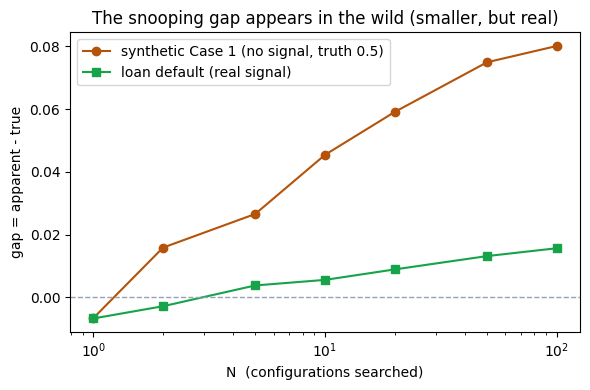

   N   gap synth   gap loan
   1     -0.007      -0.007
   2     +0.016      -0.003
   5     +0.027      +0.004
  10     +0.045      +0.006
  20     +0.059      +0.009
  50     +0.075      +0.013
 100     +0.080      +0.016


In [2]:
# Synthetic Case 1 (truth = 0.5, no signal) and real loan data, through the SAME machine.
syn = synthetic_splits(1, 20, 0.0, [1000, 200, 20000])
gap_syn = sweep(syn, N_values, np.random.default_rng(0), R=20, epochs=40)

X, y = load_loan()
loan = loan_provider(X, y, [1500, 200, 8000])
gap_loan = sweep(loan, N_values, np.random.default_rng(0), R=20, epochs=60)

g_syn  = [gap_syn[N]['gap']  for N in N_values]
g_loan = [gap_loan[N]['gap'] for N in N_values]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(N_values, g_syn,  'o-', color='#b45309', label='synthetic Case 1 (no signal, truth 0.5)')
ax.plot(N_values, g_loan, 's-', color='#16a34a', label='loan default (real signal)')
ax.axhline(0, ls='--', lw=1, color='#94a3b8')
ax.set_xscale('log')
ax.set_xlabel('N  (configurations searched)'); ax.set_ylabel('gap = apparent - true')
ax.set_title('The snooping gap appears in the wild (smaller, but real)')
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(ROOT, 'figures', 'gap_synth_vs_loan.svg'))
plt.show()

print(f"{'N':>4}   gap synth   gap loan")
for N in N_values:
    print(f'{N:>4}     {gap_syn[N]["gap"]:+.3f}      {gap_loan[N]["gap"]:+.3f}')

## Finance (^GSPC) — signal ~ 0
*To come (R3-R4): walk-forward split; the searched 'edge' is almost all luck and collapses out-of-sample - the warning case.*